### 1(a). Rule-based Classifier

The rule-based classifier follows this logic:

- **If** any of the following conditions are true:
  - Cell size is abnormal
  - Cell shape is abnormal
  - Cell texture is abnormal
  - Cell homogeneity is abnormal

- **Then**, the diagnosis is malignant.

- **Otherwise**, the diagnosis is benign.


In [240]:
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_pickle('wdbc.pkl')
df= df.drop(columns=['id'])

X=df.drop(columns=['malignant'])
y=df['malignant']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=0)

In [243]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
df = pd.read_pickle('wdbc.pkl')
df = df.drop(columns=['id'])

X = df.drop(columns=['malignant'])
y = df['malignant']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

class RuleBasedClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, thresholds=None, description='mean'):
        self.thresholds = thresholds
        self.description = description
        self.feature_groups = {
            "size": [ 'radius_2', 'area_2', 'perimeter_2'],
            "shape": ['concave points_2'],
            "texture": [ 'texture_2'],
            "homogeneity": ['symmetry_2']
    }
        
    def fit(self, X, y):
        """ No training required, but compute thresholds if not provided. """
        if self.thresholds is None:
            self.thresholds = X.describe().loc[self.description].to_dict()
        return self

    def predict(self, X):
        """ Predict malignancy based on rule-based thresholds. """
        predictions = []
        for _, row in X.iterrows():
            abnormal = any(row[feature] > self.thresholds[feature] for group in self.feature_groups.values() for feature in group)
            predictions.append(1 if abnormal else 0)
        return np.array(predictions)

# Initialize and evaluate classifier
clf = RuleBasedClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Print evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.631578947368421
Confusion Matrix:
 [[25 42]
 [ 0 47]]


In [244]:
from sklearn.model_selection import cross_val_score
clf = RuleBasedClassifier()

# Cross-validation
cv_score = cross_val_score(clf, X_train, y_train, cv=10, n_jobs=-1).mean()
print(f"Cross-validation accuracy before tuning hyperparameters: {cv_score:.4f}")

# Train on entire training set and evaluate
clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)

# Accuracy
accuracy = accuracy_score(y_train, y_pred)
print(f"Accuracy score: {accuracy:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_train, y_pred)
print("Confusion Matrix:")
print(conf_matrix)


Cross-validation accuracy before tuning hyperparameters: 0.6156
Accuracy score: 0.61
Confusion Matrix:
[[116 174]
 [  2 163]]


In [245]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_dist = {
    'description': ['mean', '50%', '75%', 'max', 'min'] # test all the values in describe()
   
    }

grid_search= GridSearchCV(RuleBasedClassifier(),param_grid=param_dist, n_jobs=-1, cv=10)
grid_search.fit(X_train,y_train)
print(f"Best parameters:{grid_search.best_params_}")
print(f"Cross validations after tuning HP: {cross_val_score(RuleBasedClassifier( description=grid_search.best_params_['description']), X_train, y_train, n_jobs=-1, cv=10).mean()}")
#print("Cross validations after tuning HP:{cross_val_score(RuleBasedClassifier(min_features_exceed=grid_search.best_params_['min_features_exceed'],description=grid_search.best_params_['description']), X_train, y_train, n_jobs=-1, cv=10).mean()}")
print(cross_val_score(grid_search.best_estimator_, X_train, y_train, n_jobs=-1, cv=5).mean())

clf_train=RuleBasedClassifier(description=grid_search.best_params_['description'])
clf_train.fit(X_train, y_train)
y_pred_train = clf_train.predict(X_train)
conf_matrix_train = confusion_matrix(y_train, y_pred_train)
print("Confusion Matrix:")
print(conf_matrix_train)


Best parameters:{'description': '75%'}
Cross validations after tuning HP: 0.8222705314009662
0.8197802197802198
Confusion Matrix:
[[218  72]
 [ 10 155]]


0.8421052631578947
F1-score: 0.8364
Precision: 0.7302
Recall: 0.9787
Confusion Matrix:
[[50 17]
 [ 1 46]]


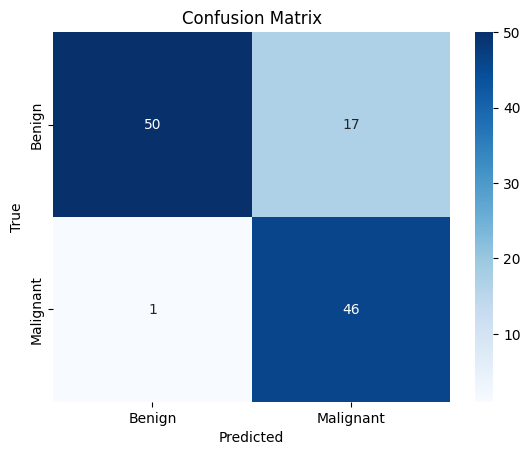

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
fin_clf=RuleBasedClassifier(description=grid_search.best_params_['description'])
#fin_clf=RuleBasedClassifier(min_features_exceed=4 ,description='mean')
fin_clf.fit(X_train, y_train)
Yguess = fin_clf.predict(X_test)
acc_score=accuracy_score(y_test, Yguess)
print(acc_score)

f1 = f1_score(y_test, Yguess)
print(f"F1-score: {f1:.4f}")
precision = precision_score(y_test, Yguess)
recall = recall_score(y_test, Yguess)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

conf_matrix = confusion_matrix(y_test, Yguess)
print("Confusion Matrix:")
print(conf_matrix)

# Plotting confusion matrix as heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### 1(b): Rule-Based Classifier (Version 2)

This version of the rule-based classifier applies a more nuanced decision-making process for predicting malignancy. Instead of classifying a sample as malignant based on a single abnormal feature, this approach requires a certain number of features to exceed their thresholds. Here's the breakdown:

- **If** at least a specified number of features (4 or more by default) exceed their respective thresholds, the diagnosis is **malignant**.
- **Otherwise**, the diagnosis is **benign**.

#### Key Features:
- **Threshold for Malignancy**: The `min_features_exceed` parameter introduces a new rule. In this implementation, a sample is considered malignant only if at least n features exceed their thresholds.
- **Feature Selection**: Only a subset of features is used for making predictions. This subset is specified in the `selected_features` list, which includes important features like `area_2`, `concavity_2`, `radius_2`, and others. This allows for more focused analysis of the relevant features rather than considering all available features.

#### Rule Logic:
- The rule checks how many features exceed their respective thresholds, summing this count in the `abnormal_count` variable.
- If this count meets or exceeds the threshold defined by `min_features_exceed`, the sample is classified as malignant (`1`), otherwise it is classified as benign (`0`).


In [250]:
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_pickle('wdbc.pkl')
df= df.drop(columns=['id'])

X=df.drop(columns=['malignant'])
y=df['malignant']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=0)

In [251]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.base import BaseEstimator, ClassifierMixin

class RuleBasedClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, thresholds=None, description='mean',min_features_exceed=4):  # Using median instead of mean
        self.thresholds = thresholds
        self.description = description
        self.min_features_exceed=min_features_exceed
        self.selected_features = [
             "area_2", "concavity_2", "concave points_2", "smoothness_2", "radius_2", "symmetry_2" , "perimeter_2", "texture_2"
        ]
    def fit(self, X, y):
        """ No training required for a rule-based classifier. """
        if self.thresholds is None:
            self.thresholds = X[self.selected_features].describe().loc[self.description].to_dict()
            #self.thresholds = X.describe().loc[self.description].to_dict()
        return self
    def predict(self, X):
        """ Predict malignancy based on feature thresholds. """
        predictions = []
        for _, row in X.iterrows():
            abnormal_count = sum(row[feature] > self.thresholds[feature] for feature in self.selected_features)
            #abnormal_count = sum(row[feature] > self.thresholds[feature] for feature in self.thresholds)
            if abnormal_count >= self.min_features_exceed:  # At least 3 features must exceed their threshold
                predictions.append(1)  # Malignant
            else:
                predictions.append(0)  # Benign
        return np.array(predictions)


    

In [252]:
from sklearn.model_selection import cross_val_score
clf = RuleBasedClassifier()

# Cross-validation
cv_score = cross_val_score(clf, X_train, y_train, cv=10, n_jobs=-1).mean()
print(f"Cross-validation accuracy before tuning hyperparameters: {cv_score:.4f}")

# Train on entire training set and evaluate
clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)

# Accuracy
accuracy = accuracy_score(y_train, y_pred)
print(f"Accuracy score: {accuracy:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_train, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Cross-validation accuracy before tuning hyperparameters: 0.9318
Accuracy score: 0.93
Confusion Matrix:
[[266  24]
 [  6 159]]


In [253]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_dist = {
    'min_features_exceed': np.arange(1, 21),  # Test values between 1 and 20
    'description': ['mean', '50%', '75%', 'max', 'min'] # test all the values in describe()
   
    }

grid_search= GridSearchCV(RuleBasedClassifier(),param_grid=param_dist, n_jobs=-1, cv=10)
grid_search.fit(X_train,y_train)
print(f"Best parameters:{grid_search.best_params_}")
print(f"Cross validations after tuning HP: {cross_val_score(RuleBasedClassifier(min_features_exceed=grid_search.best_params_['min_features_exceed'], description=grid_search.best_params_['description']), X_train, y_train, n_jobs=-1, cv=10).mean()}")
#print("Cross validations after tuning HP:{cross_val_score(RuleBasedClassifier(min_features_exceed=grid_search.best_params_['min_features_exceed'],description=grid_search.best_params_['description']), X_train, y_train, n_jobs=-1, cv=10).mean()}")
print(cross_val_score(grid_search.best_estimator_, X_train, y_train, n_jobs=-1, cv=5).mean())

clf_train=RuleBasedClassifier(min_features_exceed=grid_search.best_params_['min_features_exceed'],description=grid_search.best_params_['description'])
clf_train.fit(X_train, y_train)
y_pred_train = clf_train.predict(X_train)
conf_matrix_train = confusion_matrix(y_train, y_pred_train)
print("Confusion Matrix:")
print(conf_matrix_train)


Best parameters:{'description': 'mean', 'min_features_exceed': 5}
Cross validations after tuning HP: 0.953816425120773
0.956043956043956
Confusion Matrix:
[[284   6]
 [ 14 151]]


0.956140350877193
F1-score: 0.9485
Precision: 0.9200
Recall: 0.9787
Confusion Matrix:
[[63  4]
 [ 1 46]]


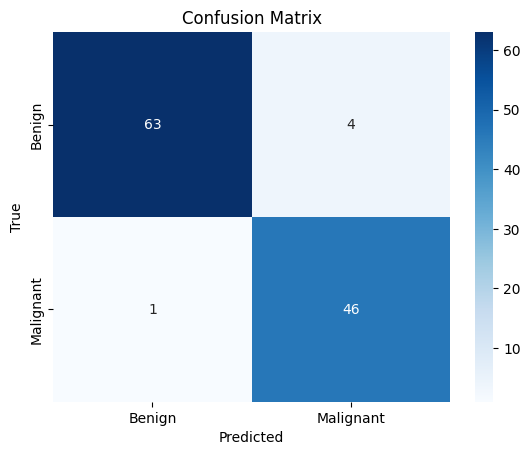

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
fin_clf=RuleBasedClassifier(min_features_exceed= grid_search.best_params_['min_features_exceed'],description=grid_search.best_params_['description'])
fin_clf=RuleBasedClassifier(min_features_exceed=4 ,description='mean')
fin_clf.fit(X_train, y_train)
Yguess = fin_clf.predict(X_test)
acc_score=accuracy_score(y_test, Yguess)
print(acc_score)

f1 = f1_score(y_test, Yguess)
print(f"F1-score: {f1:.4f}")
precision = precision_score(y_test, Yguess)
recall = recall_score(y_test, Yguess)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

conf_matrix = confusion_matrix(y_test, Yguess)
print("Confusion Matrix:")
print(conf_matrix)

# Plotting confusion matrix as heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### 2: Random Forest Classifier:

A Random Forest classifier is applied to the features given in the supplied dataset using the `sklearn` framework. The Random Forest algorithm builds multiple decision trees and merges them together to get a more accurate and stable prediction.


In [8]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
df=pd.read_pickle('wdbc.pkl')
df= df.drop(columns=['id'])

X=df.drop(columns=['malignant'])
y=df['malignant']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=0)


In [9]:
rf_clf=RandomForestClassifier()
print(f"cross valdiation before tuning: {cross_val_score(rf_clf, X_train, y_train, n_jobs=-1, cv=5).mean()}")

cross valdiation before tuning: 0.9582417582417582


In [ ]:
from sklearn.model_selection import GridSearchCV

params={
    'n_estimators': [1,10, 20, 30, 40, 50 , 100, 200, 300, 400, 500], 
    #'criterion':["gini", "entropy"],
    'max_depth': np.arange(1,21),
    #'max_features': [ 'sqrt', 'log2']
}
grid_search=GridSearchCV(rf_clf, param_grid=params, n_jobs=-1, cv=5)
grid_search.fit(X_train, y_train)
print(f"Best hyperparameters: {grid_search.best_params_}")

Best hyperparameters: {'max_depth': 8, 'n_estimators': 30}


cross valdiation after tuning: 0.9472527472527472
Confusion Matrix:
[[290   0]
 [  0 165]]


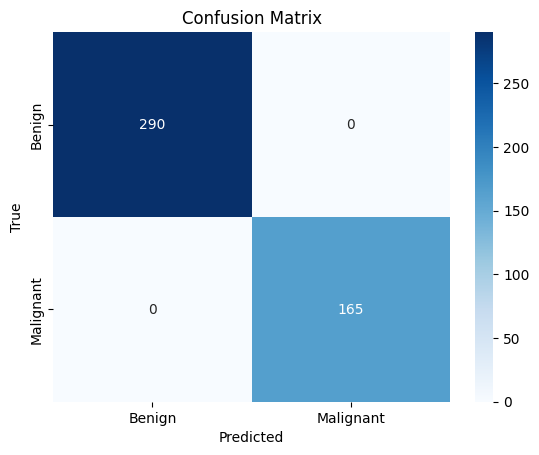

In [27]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
clf_train=RandomForestClassifier(n_estimators=grid_search.best_params_['n_estimators'],
                           #criterion=grid_search.best_params_['criterion'],
                            max_depth=grid_search.best_params_['max_depth'],
                            #max_features=grid_search.best_params_['max_features']
                            )
print(f"cross valdiation after tuning: {cross_val_score(clf_train, X_train, y_train, n_jobs=-1, cv=5).mean()}")

clf_train.fit(X_train, y_train)
y_pred_train = clf_train.predict(X_train)
conf_matrix_train = confusion_matrix(y_train, y_pred_train)
print("Confusion Matrix:")
print(conf_matrix_train)

# Plotting confusion matrix as heatmap
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [301]:
print(clf_train.feature_importances_)
X_train.columns

[0.01942422 0.01486302 0.03447883 0.0199966  0.00755163 0.01445076
 0.03956042 0.12149296 0.00562392 0.00474315 0.02771371 0.00305327
 0.01860272 0.06808941 0.00314202 0.00467551 0.00537468 0.00590403
 0.00531766 0.00515069 0.13191843 0.01567365 0.19139991 0.05714245
 0.01526615 0.01717106 0.03672826 0.09304063 0.01063856 0.00181169]


Index(['radius_0', 'texture_0', 'perimeter_0', 'area_0', 'smoothness_0',
       'compactness_0', 'concavity_0', 'concave points_0', 'symmetry_0',
       'fractal dimension_0', 'radius_1', 'texture_1', 'perimeter_1', 'area_1',
       'smoothness_1', 'compactness_1', 'concavity_1', 'concave points_1',
       'symmetry_1', 'fractal dimension_1', 'radius_2', 'texture_2',
       'perimeter_2', 'area_2', 'smoothness_2', 'compactness_2', 'concavity_2',
       'concave points_2', 'symmetry_2', 'fractal dimension_2'],
      dtype='object')

In [ ]:
import pandas as pd
feature_importance = clf_train.feature_importances_
feature_names = X_train.columns

# Combine feature names and their corresponding importances into a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})
# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# Print the sorted DataFrame
print(feature_importance_df)


                Feature  Importance
22          perimeter_2    0.191400
20             radius_2    0.131918
7      concave points_0    0.121493
27     concave points_2    0.093041
13               area_1    0.068089
23               area_2    0.057142
6           concavity_0    0.039560
26          concavity_2    0.036728
2           perimeter_0    0.034479
10             radius_1    0.027714
3                area_0    0.019997
0              radius_0    0.019424
12          perimeter_1    0.018603
25        compactness_2    0.017171
21            texture_2    0.015674
24         smoothness_2    0.015266
1             texture_0    0.014863
5         compactness_0    0.014451
28           symmetry_2    0.010639
4          smoothness_0    0.007552
17     concave points_1    0.005904
8            symmetry_0    0.005624
16          concavity_1    0.005375
18           symmetry_1    0.005318
19  fractal dimension_1    0.005151
9   fractal dimension_0    0.004743
15        compactness_1    0

0.9649122807017544
Confusion Matrix:
[[66  1]
 [ 3 44]]


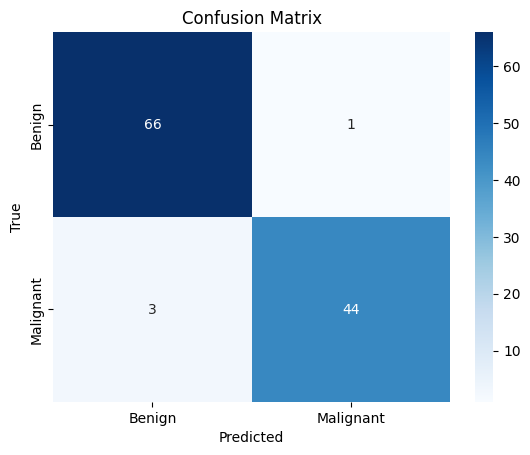

In [31]:
Yguess = clf_train.predict(X_test)
acc_score=accuracy_score(y_test, Yguess)
print(acc_score)
conf_matrix = confusion_matrix(y_test, Yguess)
print("Confusion Matrix:")
print(conf_matrix)



# Plotting confusion matrix as heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


### 3: Custom Classifier: Logistic Regression + Decision Tree Hybrid:

This custom classifier combines a **Decision Tree** and **Logistic Regression** to create a hybrid model.


Best parameters found: {'criterion': 'entropy', 'max_depth': 3}
Decision Tree - Cross-Validation Accuracy: 0.9429
Logistic Regression - Cross-Validation Accuracy: 0.9868
Accuracy of Logistic Regression + Decision Tree hybrid model: 0.9825
F1 Score: 0.9762
ROC-AUC Score: 0.9767
Confusion Matrix:
[[71  0]
 [ 2 41]]
[6.4 4.8]


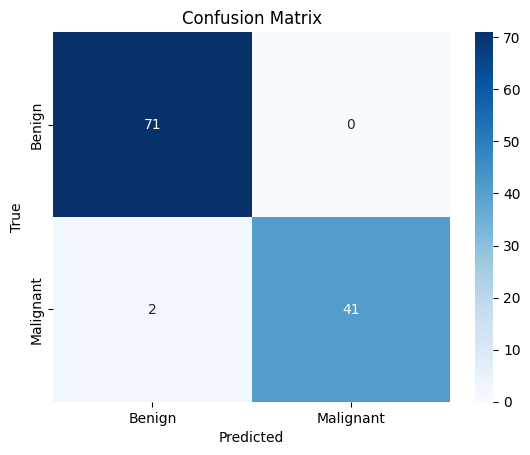

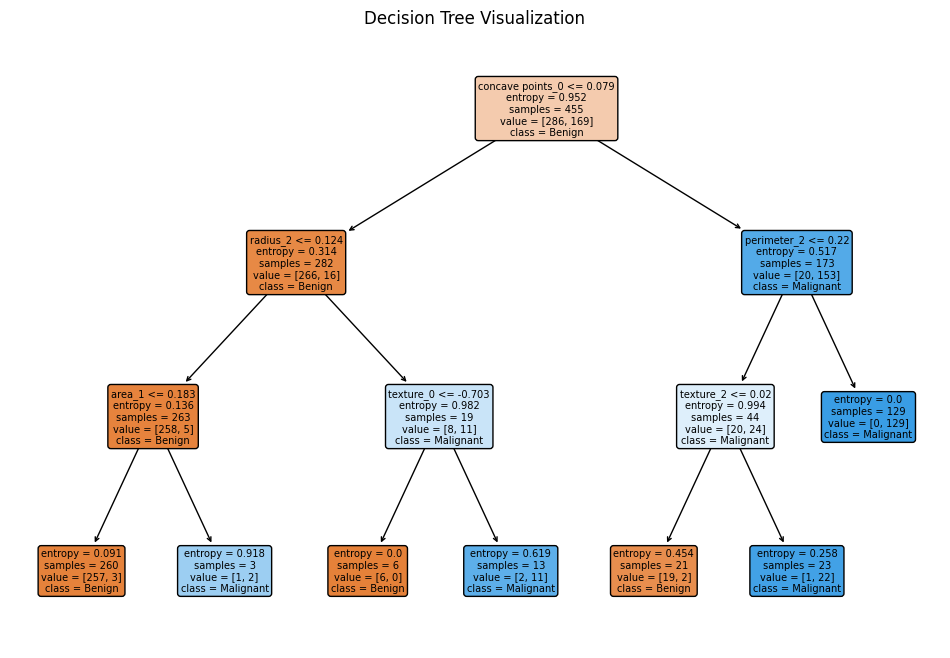

In [312]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_pickle('wdbc.pkl')
df = df.drop(columns=['id'])  # Drop the subject id

X = df.drop(columns=['malignant'])
y = df['malignant']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning for DecisionTreeClassifier using GridSearchCV
dt_classifier = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    # 'min_samples_split': [2, 5, 10],
    # 'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Apply GridSearchCV to find the best parameters
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# Best parameters found by GridSearchCV
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

# Use the best model from GridSearchCV
best_dt_classifier = grid_search.best_estimator_

# Cross-validation for the Decision Tree with optimal hyperparameters
dt_cv_score = cross_val_score(best_dt_classifier, X_train_scaled, y_train, cv=5, n_jobs=-1)
print(f"Decision Tree - Cross-Validation Accuracy: {dt_cv_score.mean():.4f}")

# Train the Decision Tree Classifier
best_dt_classifier.fit(X_train_scaled, y_train)

# Extract the leaf node assignments for each sample
leaf_train = best_dt_classifier.apply(X_train_scaled)  # This returns the leaf indices for training data
leaf_test = best_dt_classifier.apply(X_test_scaled)    # This returns the leaf indices for test data

# Add the leaf node assignments as new features to the dataset
X_train_new = np.hstack((X_train_scaled, leaf_train.reshape(-1, 1)))
X_test_new = np.hstack((X_test_scaled, leaf_test.reshape(-1, 1)))

# Step 4: Train a Logistic Regression model on the new features
log_reg_classifier = LogisticRegression(max_iter=2000, solver='liblinear')

# Cross-validation for Logistic Regression
log_reg_cv_score = cross_val_score(log_reg_classifier, X_train_new, y_train, cv=5, n_jobs=-1)
print(f"Logistic Regression - Cross-Validation Accuracy: {log_reg_cv_score.mean():.4f}")

# Train the Logistic Regression model
log_reg_classifier.fit(X_train_new, y_train)

# Evaluate the model
y_pred = log_reg_classifier.predict(X_test_new)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression + Decision Tree hybrid model: {accuracy:.4f}")

# Calculate additional metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Plotting confusion matrix as heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
print(plt.gcf().get_size_inches())
plt.show()

# Visualize the Decision Tree
plt.figure(figsize=(12,8))
plot_tree(best_dt_classifier, filled=True, feature_names=X.columns, class_names=['Benign', 'Malignant'], rounded=True)
plt.title("Decision Tree Visualization")
plt.show()
